# R05 - Reconciliation

## Objetivo
Avaliar a política de reconciliation em 5 classes de cenário
(recuperável por rota/duração/slots; irrecuperável por teto de
fidelidade/perda severa), com dados reais da campanha final
`F05_reconciliation` (20 seeds cada). Classificação de tipo de
recuperação (`strict_recovery`/`resource_adjusted_recovery`/
`sla_relaxed_recovery`) via `scripts/classify_f05_recovery_types.py` -
ver `docs/reconciliation_scope.md`. Não roda simulação - carrega apenas
dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados classificados e verificar consistência

In [2]:
CAMPAIGN = "F05_reconciliation"
trials_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "trials_with_recovery_type.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"] == 100
assert set(trials_df["recovery_type"].unique()) <= {"strict_recovery", "resource_adjusted_recovery", "sla_relaxed_recovery", "not_applicable"}
print("cases:", sorted(trials_df["case"].unique()))
trials_df.head(3)

cases: ['duration_increase_recoverable', 'fidelity_ceiling_unrecoverable', 'route_change_recoverable', 'severe_loss_attempt', 'slot_increase_recoverable']


,case,seed,episode1_route,episode1_delivered_pairs,episode1_average_fidelity,episode1_reserved_memory_slots,episode1_duration_s,initial_status,action,reconciliation_attempted,...,episodes,episode2_route,episode2_delivered_pairs,episode2_average_fidelity,episode2_reserved_memory_slots,episode2_duration_s,recovery_type,original_requirements_preserved,resource_adjustment,sla_adjustment
0,route_change_recoverable,0,r1->bad->r3,4.0,0.7695,10,0.1,VIOLATED,route_change,True,...,2,r1->good1->good2->r3,453.0,0.657922,10.0,0.1,strict_recovery,True,False,False
1,route_change_recoverable,1,r1->bad->r3,8.0,0.7695,10,0.1,VIOLATED,route_change,True,...,2,r1->good1->good2->r3,448.0,0.657922,10.0,0.1,strict_recovery,True,False,False
2,route_change_recoverable,2,r1->bad->r3,7.0,0.7695,10,0.1,VIOLATED,route_change,True,...,2,r1->good1->good2->r3,458.0,0.657922,10.0,0.1,strict_recovery,True,False,False


## Taxa de recuperação por classe (n, IC95% Wilson)

In [3]:
from scipy import stats as scipy_stats

def wilson_ci(successes, n, alpha=0.05):
    if n == 0:
        return None, None, None
    p = successes / n
    z = scipy_stats.norm.ppf(1 - alpha / 2)
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return p, max(0.0, center - half), min(1.0, center + half)

rows = []
for case, group in trials_df.groupby("case"):
    attempted = group[group["reconciliation_attempted"] == True]
    if len(attempted) == 0:
        rows.append({"case": case, "n_attempted": 0, "recovery_rate": None, "ci95_low": None, "ci95_high": None})
        continue
    successes = int(attempted["recovered"].sum())
    p, lo, hi = wilson_ci(successes, len(attempted))
    rows.append({"case": case, "n_attempted": len(attempted), "recovery_rate": p, "ci95_low": lo, "ci95_high": hi})
recovery_summary = pd.DataFrame(rows)
save_table(recovery_summary, "R05_recovery_rate_by_case", directory=TABLES_OUT)
recovery_summary

,case,n_attempted,recovery_rate,ci95_low,ci95_high
0,duration_increase_recoverable,20,1.00,0.838875,1.000000
1,fidelity_ceiling_unrecoverable,0,NaN,NaN,NaN
2,route_change_recoverable,15,1.00,0.796117,1.000000
3,severe_loss_attempt,20,0.00,0.000000,0.161125
4,slot_increase_recoverable,20,0.95,0.763869,0.991119


## Figura: taxa de recuperação por classe

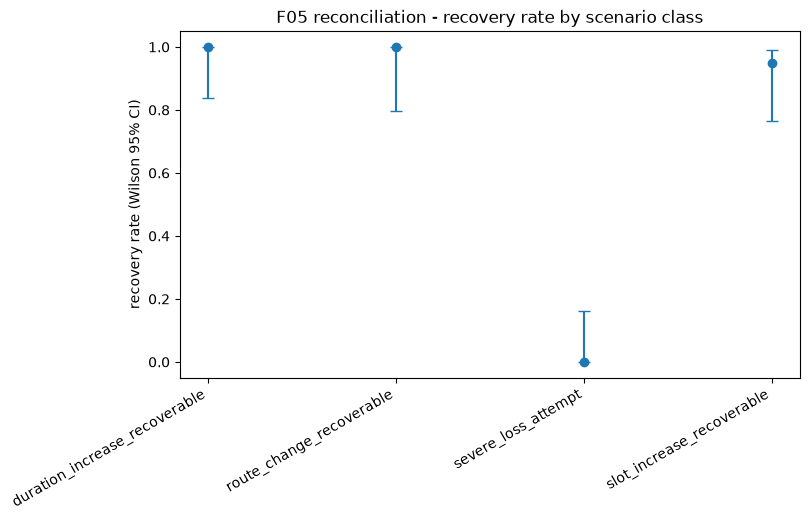

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
valid = recovery_summary.dropna(subset=["recovery_rate"])
ax.errorbar(
    range(len(valid)), valid["recovery_rate"],
    yerr=[valid["recovery_rate"] - valid["ci95_low"], valid["ci95_high"] - valid["recovery_rate"]],
    fmt="o", capsize=4,
)
ax.set_xticks(range(len(valid)))
ax.set_xticklabels(valid["case"], rotation=30, ha="right")
ax.set_ylabel("recovery rate (Wilson 95% CI)")
ax.set_title("F05 reconciliation - recovery rate by scenario class")
save_figure(fig, "R05_recovery_rate", directory=FIGURES_OUT)
plt.show()

## Conclusão

A política recuperou todos os casos de troca de rota e a maioria dos
casos de ajuste de recurso nos cenários avaliados; falhou sob perda
severa; e corretamente evitou agir num teto de fidelidade (nunca
"recovers 100% of intents", ver `docs/core_contribution_statement.md`).
`recovery_type` mostra que nem todo "recovered" preserva o contrato
original do intent - `duration_increase` altera `duration_s`.

## Limitações

O multiplicador de ajuste de recurso é fixo (2x) - nunca testado se um valor maior recuperaria o cenário de perda severa (ver `docs/reconciliation_scope.md`, `docs/future_work.md`).